<a href="https://colab.research.google.com/github/Safayat777/my_new/blob/main/Efficientnet(with_filter).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

from tensorflow.keras.utils import to_categorical
from itertools import cycle

In [2]:
train_path = "/content/drive/MyDrive/DataSet/Train"
test_path  = "/content/drive/MyDrive/DataSet/Test"

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 5

In [3]:
def clahe_median_preprocessing(img):

    img = img.astype(np.uint8)

    # Median Filter
    img = cv2.medianBlur(img, 3)

    # CLAHE
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)

    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    l = clahe.apply(l)

    lab = cv2.merge((l,a,b))

    img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    img = img.astype(np.float32) / 255.0

    return img

In [4]:
train_datagen = ImageDataGenerator(
    preprocessing_function=clahe_median_preprocessing,
    rotation_range=30,
    zoom_range=0.25,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(
    preprocessing_function=clahe_median_preprocessing
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 6659 images belonging to 2 classes.
Found 2233 images belonging to 2 classes.


In [5]:
input_layer = Input(shape=(224,224,3))

x = Conv2D(32,(3,3),activation='relu',padding='same')(input_layer)
x = BatchNormalization()(x)

x = Conv2D(32,(3,3),activation='relu')(x)
x = MaxPooling2D()(x)

x = Conv2D(64,(3,3),activation='relu',padding='same')(x)
x = BatchNormalization()(x)

x = Conv2D(64,(3,3),activation='relu')(x)
x = MaxPooling2D()(x)

x = Conv2D(128,(3,3),activation='relu',padding='same')(x)
x = BatchNormalization()(x)

x = Conv2D(128,(3,3),activation='relu')(x)
x = MaxPooling2D()(x)

x = Conv2D(256,(3,3),activation='relu')(x)
x = BatchNormalization()(x)

x = MaxPooling2D()(x)

cnn_features = GlobalAveragePooling2D()(x)
cnn_features = Dense(256, activation='relu')(cnn_features)

In [6]:
base_model = EfficientNetB4(
    weights='imagenet',
    include_top=False,
    input_tensor=input_layer
)

for layer in base_model.layers[:-30]:
    layer.trainable = False

y = base_model.output

71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [7]:
def se_block(input_tensor, ratio=8):

    filters = input_tensor.shape[-1]

    se = GlobalAveragePooling2D()(input_tensor)

    se = Dense(filters//ratio,
               activation='relu')(se)

    se = Dense(filters,
               activation='sigmoid')(se)

    se = Reshape((1,1,filters))(se)

    return Multiply()([input_tensor,se])

attention = se_block(y)

attention = GlobalAveragePooling2D()(attention)

# Reduce attention dimension
attention = Dense(256,
                  activation='relu')(attention)

In [8]:
y = GlobalAveragePooling2D()(y)

y = Dense(512,
          activation='relu')(y)

y = BatchNormalization()(y)

y = Dense(256,
          activation='relu')(y)

y = Dropout(0.5)(y)

efficient_features = Dense(
    256,
    activation='relu'
)(y)

In [9]:
combined = Concatenate()(
    [
        cnn_features,
        efficient_features,
        attention
    ]
)

In [10]:
z = Dense(512,
          activation='relu')(combined)

z = BatchNormalization()(z)

z = Dense(256,
          activation='relu')(z)

z = Dropout(0.5)(z)

z = Dense(128,
          activation='relu')(z)

z = Dropout(0.4)(z)

output = Dense(
    train_generator.num_classes,
    activation='softmax'
)(z)

In [11]:
model = Model(
    inputs=input_layer,
    outputs=output
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │      1,296 │ stem_conv_pad[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        192 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        432 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        192 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 48)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 48)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 12)  │        588 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 48)  │        624 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 48)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      1,152 │ block1a_se_excit

 Total params: 21,264,993 (81.12 MB)

 Trainable params: 8,420,662 (32.12 MB)

 Non-trainable params: 12,844,331 (49.00 MB)

In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    verbose=1
)

In [14]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=EPOCHS,
    callbacks=[
        early_stop,
        reduce_lr
    ]
)


Epoch 1/5
209/209 ━━━━━━━━━━━━━━━━━━━━ 4434s 21s/step - accuracy: 0.7174 - loss: 0.6399 - val_accuracy: 0.5034 - val_loss: 1.8918 - learning_rate: 1.0000e-04
Epoch 2/5
209/209 ━━━━━━━━━━━━━━━━━━━━ 3368s 16s/step - accuracy: 0.8126 - loss: 0.4291 - val_accuracy: 0.5034 - val_loss: 3.4641 - learning_rate: 1.0000e-04
Epoch 3/5
209/209 ━━━━━━━━━━━━━━━━━━━━ 3448s 17s/step - accuracy: 0.8392 - loss: 0.3817 - val_accuracy: 0.4881 - val_loss: 2.2155 - learning_rate: 1.0000e-04
Epoch 4/5
209/209 ━━━━━━━━━━━━━━━━━━━━ 3481s 17s/step - accuracy: 0.8665 - loss: 0.3100 - val_accuracy: 0.8115 - val_loss: 0.4972 - learning_rate: 1.0000e-04
Epoch 5/5
209/209 ━━━━━━━━━━━━━━━━━━━━ 3477s 17s/step - accuracy: 0.8850 - loss: 0.2746 - val_accuracy: 0.7927 - val_loss: 0.4251 - learning_rate: 1.0000e-04


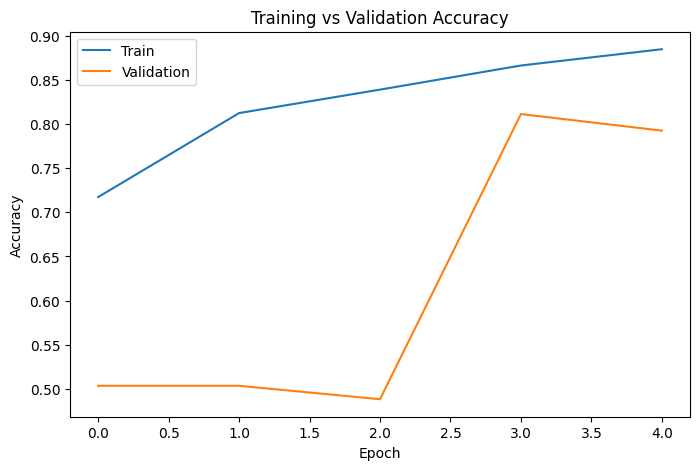

In [15]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Train",
    "Validation"
])

plt.show()

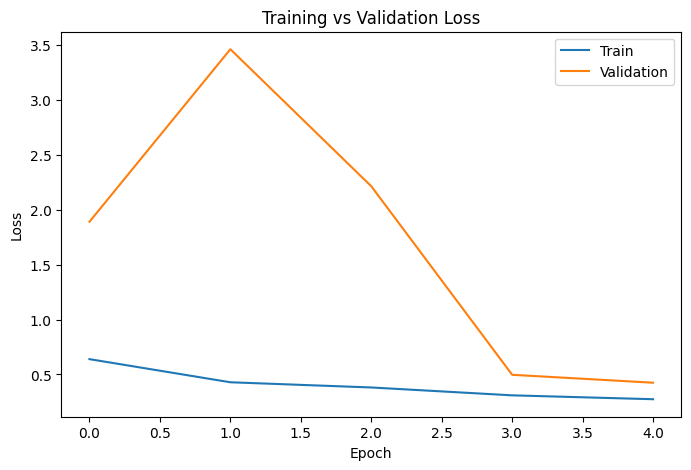

In [16]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Train",
    "Validation"
])

plt.show()

In [17]:
loss, accuracy = model.evaluate(
    test_generator
)

print("\nTest Accuracy:", accuracy)

70/70 ━━━━━━━━━━━━━━━━━━━━ 460s 7s/step - accuracy: 0.7927 - loss: 0.4251

Test Accuracy: 0.7926556468009949


In [18]:
pred = model.predict(
    test_generator
)

y_pred = np.argmax(
    pred,
    axis=1
)

y_true = test_generator.classes

70/70 ━━━━━━━━━━━━━━━━━━━━ 455s 6s/step


In [19]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=list(
            train_generator.class_indices.keys()
        )
    )
)

              precision    recall  f1-score   support

    infected       0.80      0.77      0.79      1109
not_infected       0.78      0.81      0.80      1124

    accuracy                           0.79      2233
   macro avg       0.79      0.79      0.79      2233
weighted avg       0.79      0.79      0.79      2233



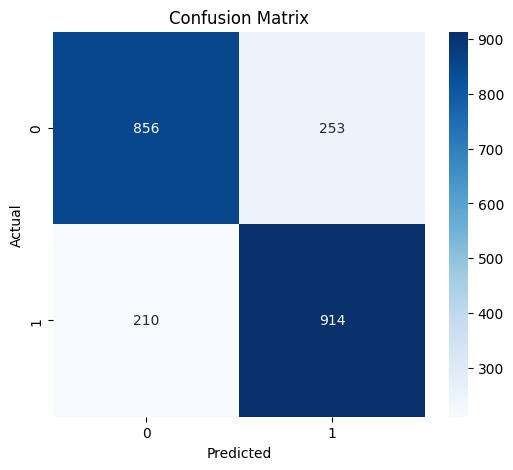

In [20]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

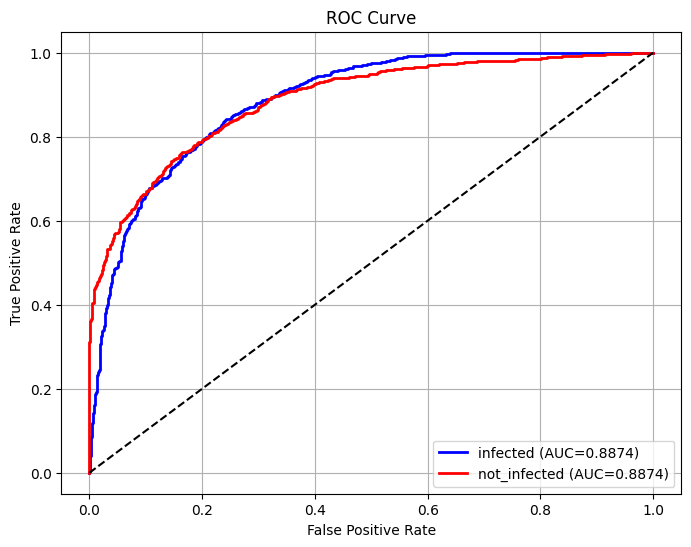

In [21]:
n_classes = train_generator.num_classes

y_true_bin = to_categorical(
    y_true,
    num_classes=n_classes
)

y_score = pred

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):

    fpr[i], tpr[i], _ = roc_curve(
        y_true_bin[:, i],
        y_score[:, i]
    )

    roc_auc[i] = auc(
        fpr[i],
        tpr[i]
    )

plt.figure(figsize=(8,6))

colors = cycle(
    [
        'blue',
        'red',
        'green',
        'orange',
        'purple'
    ]
)

class_names = list(
    train_generator.class_indices.keys()
)

for i, color in zip(
    range(n_classes),
    colors
):

    plt.plot(
        fpr[i],
        tpr[i],
        color=color,
        lw=2,
        label=f'{class_names[i]} '
              f'(AUC={roc_auc[i]:.4f})'
    )

plt.plot(
    [0,1],
    [0,1],
    'k--'
)

plt.xlabel(
    'False Positive Rate'
)

plt.ylabel(
    'True Positive Rate'
)

plt.title(
    'ROC Curve'
)

plt.legend(
    loc='lower right'
)

plt.grid()

plt.show()